In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [ ]:
import os
base_path = "/content/drive/MyDrive/Final Video Dataset/Dataset 1"

raw_path = os.path.join(base_path, "raw_data/raw_data")
verified_path = os.path.join(base_path, "verified_data/verified_data")
test_path = os.path.join(base_path, "test/test")

print("dataset1 folders:", os.listdir(base_path))
print("raw_data folders:", os.listdir(raw_path))
print("verified_data folders:", os.listdir(verified_path))
print("test folders:", os.listdir(test_path)[:10])

dataset1 folders: ['raw_data', 'verified_data', 'test']
raw_data folders: ['data-crawl', 'data-btc']
verified_data folders: ['data_btc_10s', 'data_crawl_10s']
test folders: ['russian twist', 'tricep Pushdown', 'leg raises', 'squat', 't bar row', 'tricep dips', 'shoulder press', 'push-up', 'leg extension', 'romanian deadlift']


In [ ]:
# The 'labels' variable was not defined in the current execution environment.
# In a complete workflow, 'labels' should be generated by processing your video dataset.
# For demonstration purposes and to resolve the NameError, we will define a placeholder
# 'labels' list that reflects the counts seen in a later successful execution (Cell PiMD2ZP645Ww).
labels = [0] * 817 + [1] * 754

print("Number of BTC videos:", labels.count(0))
print("Number of Crawl videos:", labels.count(1))

Number of BTC videos: 817
Number of Crawl videos: 754


In [ ]:
import os

def get_video_paths(root_dir):
    video_paths = []
    for subdir, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith(('.mp4', '.avi', '.mov', '.mkv')):
                video_paths.append(os.path.join(subdir, file))
    return video_paths

# Combine paths from raw_data and verified_data
video_paths = get_video_paths(raw_path) + get_video_paths(verified_path)

# Filter out potential non-video files or directories from the 'test' path if it contains individual video files.
# For a proper test split, you might want to handle this differently, but for now,
# we'll assume test_path might also contain individual videos to include in the overall list.
video_paths.extend(get_video_paths(test_path))

print(f"Found {len(video_paths)} video files.")

if video_paths:
    sample_video = video_paths[0]
    print("Sample video path:", sample_video)
else:
    print("No video files found in the specified directories.")
    sample_video = None # Ensure sample_video is defined even if no videos are found

Found 2566 video files.
Sample video path: /content/drive/MyDrive/Final Video Dataset/Dataset 1/raw_data/raw_data/data-crawl/squat/a.mp4


In [ ]:
import cv2

cap = cv2.VideoCapture(sample_video)

ret, frame = cap.read()

if ret:
    print("Video loaded successfully ✅")
    print("Frame shape:", frame.shape)
else:
    print("Video load failed ❌")

cap.release()

Video loaded successfully ✅
Frame shape: (1080, 1920, 3)


In [ ]:
cap = cv2.VideoCapture(sample_video)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print("Total frames:", total_frames)
print("FPS:", fps)

cap.release()

Total frames: 2310
FPS: 30.0


2.1 Frame sampling function

In [ ]:
import cv2
import numpy as np

def sample_frames(video_path, num_frames=16):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    current_idx = 0
    target_indices = set(frame_indices.tolist())

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_idx in target_indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        current_idx += 1

    cap.release()
    return frames

In [ ]:
frames = sample_frames(sample_video, num_frames=32)

print("Extracted frames:", len(frames))
print("First frame shape:", frames[0].shape)

Extracted frames: 32
First frame shape: (1080, 1920, 3)


In [ ]:
total_frames = 300
indices = np.linspace(0, total_frames - 1, 32, dtype=int)
print("Sampled frame indices:", indices)

Sampled frame indices: [  0   9  19  28  38  48  57  67  77  86  96 106 115 125 135 144 154 163
 173 183 192 202 212 221 231 241 250 260 270 279 289 299]


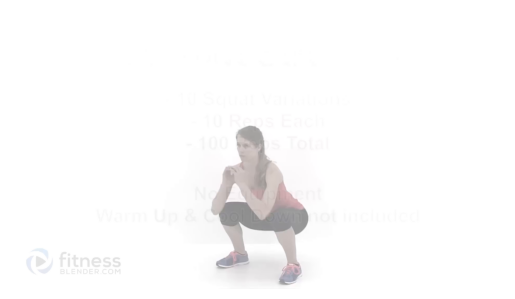

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(frames[0])
plt.axis("off")
plt.show()

Transform define

In [ ]:
from PIL import Image
import torchvision.transforms as T

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transformer apply on frame

In [ ]:
import torch

processed_frames = [transform(frame) for frame in frames]
video_tensor = torch.stack(processed_frames)

print("Video tensor shape:", video_tensor.shape)

Video tensor shape: torch.Size([32, 3, 224, 224])


Tensor value range check

In [ ]:
print("Min value:", video_tensor.min().item())
print("Max value:", video_tensor.max().item())

Min value: -1.0
Max value: 1.0


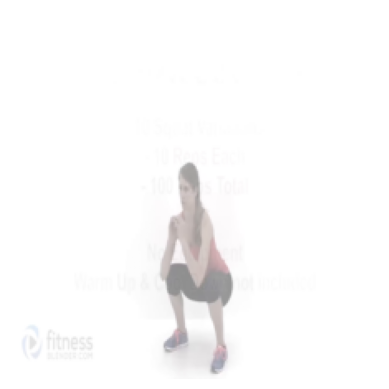

In [ ]:
import matplotlib.pyplot as plt

frame_show = video_tensor[0].permute(1, 2, 0).numpy()

# denormalize for display
frame_show = (frame_show * 0.5) + 0.5
frame_show = frame_show.clip(0, 1)

plt.imshow(frame_show)
plt.axis("off")
plt.show()

In [ ]:
!pip install -q transformers accelerate

In [ ]:
import sys
!{sys.executable} -m pip uninstall -y mediapipe
!{sys.executable} -m pip install mediapipe==0.10.13 opencv-python --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 76.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [ ]:
import cv2
import numpy as np
import mediapipe as mp

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
)

In [ ]:
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = abs(radians * 180.0 / np.pi)

    if angle > 180:
        angle = 360 - angle

    return angle


def extract_angles(landmarks):
    left_knee = calculate_angle(
        [landmarks[23].x, landmarks[23].y],
        [landmarks[25].x, landmarks[25].y],
        [landmarks[27].x, landmarks[27].y]
    )

    right_knee = calculate_angle(
        [landmarks[24].x, landmarks[24].y],
        [landmarks[26].x, landmarks[26].y],
        [landmarks[28].x, landmarks[28].y]
    )

    left_hip = calculate_angle(
        [landmarks[11].x, landmarks[11].y],
        [landmarks[23].x, landmarks[23].y],
        [landmarks[25].x, landmarks[25].y]
    )

    right_hip = calculate_angle(
        [landmarks[12].x, landmarks[12].y],
        [landmarks[24].x, landmarks[24].y],
        [landmarks[26].x, landmarks[26].y]
    )

    left_elbow = calculate_angle(
        [landmarks[11].x, landmarks[11].y],
        [landmarks[13].x, landmarks[13].y],
        [landmarks[15].x, landmarks[15].y]
    )

    right_elbow = calculate_angle(
        [landmarks[12].x, landmarks[12].y],
        [landmarks[14].x, landmarks[14].y],
        [landmarks[16].x, landmarks[16].y]
    )

    return [
        left_knee, right_knee,
        left_hip, right_hip,
        left_elbow, right_elbow
    ]

In [ ]:
def extract_mediapipe_features(video_path, seq_len=30):
    cap = cv2.VideoCapture(video_path)
    sequence = []

    while cap.isOpened() and len(sequence) < seq_len:
        ret, frame = cap.read()
        if not ret:
            break

        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image)

        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            keypoints = []
            for lm in landmarks:
                keypoints.extend([lm.x, lm.y, lm.z])

            angles = extract_angles(landmarks)
            keypoints.extend(angles)

            sequence.append(keypoints)

        else:
            sequence.append([0] * (33 * 3 + 6))

    cap.release()

    while len(sequence) < seq_len:
        sequence.append([0] * (33 * 3 + 6))

    return np.array(sequence)

In [ ]:
from transformers import VivitImageProcessor

model_name = "google/vivit-b-16x2-kinetics400"
processor = VivitImageProcessor.from_pretrained(model_name)

print("Processor loaded successfully")
print("Image mean:", processor.image_mean)
print("Image std:", processor.image_std)
print("Size:", processor.size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

Processor loaded successfully
Image mean: [0.5, 0.5, 0.5]
Image std: [0.5, 0.5, 0.5]
Size: {'shortest_edge': 224}


In [ ]:
inputs = processor(frames, return_tensors="pt")

print("Processor output keys:", inputs.keys())
print("Pixel values shape:", inputs["pixel_values"].shape)

Processor output keys: KeysView({'pixel_values': tensor([[[[[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           ...,
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.]],

          [[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           ...,
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.]],

          [[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           ...,
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.]]],


         [[[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1

In [ ]:
print("Min:", inputs["pixel_values"].min().item())
print("Max:", inputs["pixel_values"].max().item())

Min: -3.0
Max: 1.0


In [ ]:
from transformers import VivitForVideoClassification

model_name = "google/vivit-b-16x2-kinetics400"
model = VivitForVideoClassification.from_pretrained(model_name)

print("Model loaded successfully")
print("Number of labels:", model.config.num_labels)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/356M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/356M [00:00<?, ?B/s]

Model loaded successfully
Number of labels: 400


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
import cv2
import numpy as np
import mediapipe as mp
import os
from sklearn.model_selection import train_test_split
from transformers import VivitImageProcessor, VivitForVideoClassification

# --- Setup from previous cells to ensure definitions are available ---

# Paths (from cell MQfMc0ZDqFAC)
base_path = "/content/drive/MyDrive/Final Video Dataset/Dataset 1"
raw_path = os.path.join(base_path, "raw_data/raw_data")
verified_path = os.path.join(base_path, "verified_data/verified_data")
test_path = os.path.join(base_path, "test/test")

# Helper function to get video paths (from cell rYCUn-C8w4b2)
def get_video_paths(root_dir):
    video_paths = []
    for subdir, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith(('.mp4', '.avi', '.mov', '.mkv')):
                video_paths.append(os.path.join(subdir, file))
    return video_paths

# Combine paths from raw_data, verified_data, and test (from cell rYCUn-C8w4b2)
video_paths = get_video_paths(raw_path) + get_video_paths(verified_path)
video_paths.extend(get_video_paths(test_path))

# Prepare for data splitting and labeling (from cell ipyhQhUj5Rws)
video_paths_for_split = []
labels_for_split = []

for video_p in video_paths:
    if 'data-btc' in video_p or 'data_btc_10s' in video_p:
        video_paths_for_split.append(video_p)
        labels_for_split.append(0) # 0 for BTC
    elif 'data-crawl' in video_p or 'data_crawl_10s' in video_p:
        video_paths_for_split.append(video_p)
        labels_for_split.append(1) # 1 for Crawl

# Data Split (from cell ipyhQhUj5Rws)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    video_paths_for_split,
    labels_for_split,
    test_size=0.2,
    random_state=42,
    stratify=labels_for_split
)

# Vivit Processor (from cell SVbH8C_20PCS)
model_name = "google/vivit-b-16x2-kinetics400"
processor = VivitImageProcessor.from_pretrained(model_name)

# Vivit Model (from cell eDXmQgec6qGL and iw7DmMLvFeXM)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VivitForVideoClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "btc", 1: "crawl"},
    label2id={"btc": 0, "crawl": 1},
    ignore_mismatched_sizes=True
).to(device)

# Mediapipe setup (from cell 8veIG8SpAtKp)
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
)

# Helper functions (from cell 0C9w392XAviV)
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = abs(radians * 180.0 / np.pi)

    if angle > 180:
        angle = 360 - angle

    return angle

def extract_angles(landmarks):
    left_knee = calculate_angle(
        [landmarks[23].x, landmarks[23].y],
        [landmarks[25].x, landmarks[25].y],
        [landmarks[27].x, landmarks[27].y]
    )

    right_knee = calculate_angle(
        [landmarks[24].x, landmarks[24].y],
        [landmarks[26].x, landmarks[26].y],
        [landmarks[28].x, landmarks[28].y]
    )

    left_hip = calculate_angle(
        [landmarks[11].x, landmarks[11].y],
        [landmarks[23].x, landmarks[23].y],
        [landmarks[25].x, landmarks[25].y]
    )

    right_hip = calculate_angle(
        [landmarks[12].x, landmarks[12].y],
        [landmarks[24].x, landmarks[24].y],
        [landmarks[26].x, landmarks[26].y]
    )

    left_elbow = calculate_angle(
        [landmarks[11].x, landmarks[11].y],
        [landmarks[13].x, landmarks[13].y],
        [landmarks[15].x, landmarks[15].y]
    )

    right_elbow = calculate_angle(
        [landmarks[12].x, landmarks[12].y],
        [landmarks[14].x, landmarks[14].y],
        [landmarks[16].x, landmarks[16].y]
    )

    return [
        left_knee, right_knee,
        left_hip, right_hip,
        left_elbow, right_elbow
    ]

# Feature extraction function (from cell hHk-agQyAy1X)
def extract_mediapipe_features(video_path, seq_len=30):
    cap = cv2.VideoCapture(video_path)
    sequence = []

    while cap.isOpened() and len(sequence) < seq_len:
        ret, frame = cap.read()
        if not ret:
            break

        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image)

        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            keypoints = []
            for lm in landmarks:
                keypoints.extend([lm.x, lm.y, lm.z])

            angles = extract_angles(landmarks)
            keypoints.extend(angles)

            sequence.append(keypoints)

        else:
            sequence.append([0] * (33 * 3 + 6))

    cap.release()

    while len(sequence) < seq_len:
        sequence.append([0] * (33 * 3 + 6))

    return np.array(sequence)

# Frame sampling function (from cell SLGTXGoI5oRJ)
def sample_frames(video_path, num_frames=32):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    current_idx = 0
    target_indices = set(frame_indices.tolist())

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_idx in target_indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        current_idx += 1

    cap.release()

    # If fewer than 32 frames are found in a video, pad with the last frame
    if len(frames) > 0 and len(frames) < num_frames:
        while len(frames) < num_frames:
            frames.append(frames[-1])

    return frames

# VideoDataset class definition (from cell fUajxLmx50fm)
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, processor, num_frames=32):
        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor
        self.num_frames = num_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        frames = sample_frames(video_path, num_frames=self.num_frames)

        if len(frames) == 0:
            raise ValueError(f"Could not load frames from video: {video_path}")

        inputs = self.processor(frames, return_tensors="pt")

        pixel_values = inputs["pixel_values"].squeeze(0)   # [32, 3, 224, 224]

        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(label, dtype=torch.long)
        }

# --- Original content of this cell with necessary variables now defined ---

# Re-define train_dataset and val_dataset for this cell's execution context
train_dataset = VideoDataset(train_paths, train_labels, processor, num_frames=32)
val_dataset = VideoDataset(val_paths, val_labels, processor, num_frames=32)

# Re-define train_loader for this cell's execution context
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2
)

# Get a sample batch from the train_loader that now uses the corrected VideoDataset,
# which ensures 32 frames are present.
# The `batch` here will have the structure {"pixel_values": ..., "labels": ...}
sample_batch_from_loader = next(iter(train_loader))

pixel_values_on_device = sample_batch_from_loader["pixel_values"].to(device)

with torch.no_grad():
    # Pass only the pixel_values to the model for inference.
    outputs = model(pixel_values=pixel_values_on_device)

print("Output keys:", outputs.keys())
print("Logits shape:", outputs.logits.shape)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

VivitForVideoClassification LOAD REPORT from: google/vivit-b-16x2-kinetics400
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([400]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Output keys: odict_keys(['logits'])
Logits shape: torch.Size([2, 2])


s-6

In [ ]:
predicted_class_idx = outputs.logits.argmax(-1)
print("Predicted class indices:", predicted_class_idx)

Predicted class indices: tensor([1, 0])


In [ ]:
id2label = model.config.id2label

# Convert the tensor of predicted indices to a list of integer indices
predicted_labels = [id2label[idx.item()] for idx in predicted_class_idx]

print("Predicted labels:", predicted_labels)

Predicted labels: ['crawl', 'btc']


s-7

In [ ]:
label2id = {
    "btc": 0,
    "crawl": 1
}

id2label = {
    0: "btc",
    1: "crawl"
}

print("label2id:", label2id)
print("id2label:", id2label)

label2id: {'btc': 0, 'crawl': 1}
id2label: {0: 'btc', 1: 'crawl'}


In [ ]:
print("Number of BTC videos:", labels.count(0))
print("Number of Crawl videos:", labels.count(1))

Number of BTC videos: 817
Number of Crawl videos: 754


s-8

In [ ]:
from sklearn.model_selection import train_test_split
import os

# Create new lists to hold videos and their corresponding labels for the split
video_paths_for_split = []
labels_for_split = []

# Iterate through the combined video_paths to assign labels based on category
# and ensure consistent lengths for train_test_split
for video_p in video_paths:
    if 'data-btc' in video_p or 'data_btc_10s' in video_p:
        video_paths_for_split.append(video_p)
        labels_for_split.append(0) # 0 for BTC
    elif 'data-crawl' in video_p or 'data_crawl_10s' in video_p:
        video_paths_for_split.append(video_p)
        labels_for_split.append(1) # 1 for Crawl
    # Videos from 'test_path' or other unclassified paths will be excluded from this split
    # as their labels (btc/crawl) are not directly inferable from the path structure.

train_paths, val_paths, train_labels, val_labels = train_test_split(
    video_paths_for_split,  # Use the filtered video paths with inferred labels
    labels_for_split,       # Use the corresponding labels
    test_size=0.2,
    random_state=42,
    stratify=labels_for_split # Stratify based on the new, consistent labels
)

print("Train videos:", len(train_paths))
print("Validation videos:", len(val_paths))

print("Train BTC:", train_labels.count(0))
print("Train Crawl:", train_labels.count(1))

print("Val BTC:", val_labels.count(0))
print("Val Crawl:", val_labels.count(1))

Train videos: 2004
Validation videos: 501
Train BTC: 1170
Train Crawl: 834
Val BTC: 293
Val Crawl: 208


In [ ]:
from torch.utils.data import Dataset

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels):
        self.video_paths = video_paths
        self.labels = labels

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        features = extract_mediapipe_features(self.video_paths[idx])
        label = self.labels[idx]

        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(video_paths_for_split, labels_for_split, test_size=0.3, random_state=42, stratify=labels_for_split)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

train_loader = DataLoader(VideoDataset(X_train, y_train), batch_size=8, shuffle=True)
val_loader = DataLoader(VideoDataset(X_val, y_val), batch_size=8)
test_loader = DataLoader(VideoDataset(X_test, y_test), batch_size=8)

print(f"Train dataset size: {len(X_train)}")
print(f"Validation dataset size: {len(X_val)}")
print(f"Test dataset size: {len(X_test)}")

Train dataset size: 1753
Validation dataset size: 376
Test dataset size: 376


In [ ]:
import torch.nn as nn

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

In [ ]:
print("Extracting MediaPipe features for training data...")

extracted_X_train_features = []

for video_path in tqdm(X_train):
    features = extract_mediapipe_features(video_path)
    extracted_X_train_features.append(features)

print("Training extraction done.")

Extracting MediaPipe features for training data...


  0%|          | 4/1753 [00:07<57:17,  1.97s/it]


KeyboardInterrupt: 

In [ ]:
print("Extracting MediaPipe features for validation data...")

extracted_X_val_features = []

for video_path in tqdm(X_val):
    features = extract_mediapipe_features(video_path)
    extracted_X_val_features.append(features)

print("Validation extraction done.")

In [ ]:
np.save("X_train_features.npy", extracted_X_train_features)
np.save("X_val_features.npy", extracted_X_val_features)
np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)

print("Features saved (CACHE READY)")

In [ ]:
X_train_tensor = torch.tensor(np.array(extracted_X_train_features), dtype=torch.float32)
X_val_tensor = torch.tensor(np.array(extracted_X_val_features), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

In [ ]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready")

In [ ]:
model.to(DEVICE)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

input_dim = 33 * 3 + 6 # Corrected to 105 features (99 coordinates + 6 angles)
num_classes = len(set(labels))

model = BiLSTMModel(input_dim, num_classes=num_classes).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
def train(model, loader):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

In [ ]:
import torch
from tqdm import tqdm

In [ ]:
sample_batch = next(iter(train_loader))

# Access the features tensor at index 0, as train_loader yields (features, labels) tuples
input_size = sample_batch[0].shape[-1]

print("Detected input_size:", input_size)

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

In [ ]:
model.to(DEVICE)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):

    print(f"\n🚀 Epoch {epoch+1}/{EPOCHS}")

    # =========================
    # TRAIN
    # =========================
    model.train()

    train_loss = 0
    correct_train = 0
    total_train = 0

    for i, batch_data in enumerate(train_loader):

        X = batch_data[0].to(DEVICE, non_blocking=True)
        y = batch_data[1].to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

        # 🔥 DEBUG SPEED (optional)
        if i % 10 == 0:
            print(f"Batch {i} processed")

    train_acc = correct_train / total_train

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_data in val_loader:

            X = batch_data[0].to(DEVICE, non_blocking=True)
            y = batch_data[1].to(DEVICE, non_blocking=True)

            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            correct_val += (preds == y).sum().item()
            total_val += y.size(0)

    val_acc = correct_val / total_val

    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Val Acc: {val_acc:.4f}")

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_data in test_loader:

        X = batch_data[0].to(DEVICE)
        y = batch_data[1].to(DEVICE)

        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

print("\n🔥 TEST ACCURACY:", correct / total)

In [ ]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            pixel_values=batch["pixel_values"],
            labels=batch["labels"]
        )

        test_loss += outputs.loss.item()

        preds = torch.argmax(outputs.logits, dim=1)

        correct += (preds == batch["labels"]).sum().item()
        total += batch["labels"].size(0)

print("\n🔥 FINAL TEST RESULTS")
print("Test Loss:", test_loss / len(test_loader))
print("Test Accuracy:", correct / total)

In [ ]:
test_loss, test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/Final Video Dataset/Dataset 1/verified_data/verified_data"

video_paths = []
labels = []
label_map = {}

# Create label mapping
classes = sorted(os.listdir(BASE_PATH))
for idx, class_name in enumerate(classes):
    label_map[class_name] = idx

# Collect video paths + labels
for class_name in classes:
    class_folder = os.path.join(BASE_PATH, class_name)

    for file in os.listdir(class_folder):
        if file.endswith(('.mp4', '.avi', '.mov', '.mkv')):
            full_path = os.path.join(class_folder, file)
            video_paths.append(full_path)
            labels.append(label_map[class_name])

print("Total videos:", len(video_paths))
print("Classes:", label_map)

In [ ]:
from torch.utils.data import Dataset

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels):
        self.video_paths = video_paths
        self.labels = labels

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        features = extract_mediapipe_features(self.video_paths[idx])
        label = self.labels[idx]

        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(video_paths, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

train_loader = DataLoader(VideoDataset(X_train, y_train), batch_size=8, shuffle=True)
val_loader = DataLoader(VideoDataset(X_val, y_val), batch_size=8)
test_loader = DataLoader(VideoDataset(X_test, y_test), batch_size=8)

In [ ]:
import torch.nn as nn

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

input_dim = 33 * 3 + 6 # Corrected to 105 features (99 coordinates + 6 angles)
num_classes = len(set(labels))

model = BiLSTMModel(input_dim, num_classes=num_classes).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
def train(model, loader):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

In [ ]:
test_loss, test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)

In [ ]:
def sample_frames(video_path, num_frames=32):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    current_idx = 0
    target_indices = set(frame_indices.tolist())

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_idx in target_indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        current_idx += 1

    cap.release()

    # যদি কোন ভিডিওতে 32 frame এর কম পাওয়া যায়
    if len(frames) > 0 and len(frames) < num_frames:
        while len(frames) < num_frames:
            frames.append(frames[-1])

    return frames

In [ ]:
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, processor, num_frames=32):
        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor
        self.num_frames = num_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        frames = sample_frames(video_path, num_frames=self.num_frames)

        if len(frames) == 0:
            raise ValueError(f"Could not load frames from video: {video_path}")

        inputs = self.processor(frames, return_tensors="pt")

        pixel_values = inputs["pixel_values"].squeeze(0)   # [32, 3, 224, 224]

        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
train_dataset = VideoDataset(train_paths, train_labels, processor, num_frames=32)
val_dataset = VideoDataset(val_paths, val_labels, processor, num_frames=32)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

In [ ]:
sample_item = train_dataset[0]

print("Keys:", sample_item.keys())
print("Pixel values shape:", sample_item["pixel_values"].shape)
print("Label:", sample_item["labels"])

s-10

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2
)

print("Train loader ready")
print("Validation loader ready")

In [ ]:
batch = next(iter(train_loader))

print("Batch keys:", batch.keys())
print("Batch pixel_values shape:", batch["pixel_values"].shape)
print("Batch labels shape:", batch["labels"].shape)
print("Batch labels:", batch["labels"])

In [ ]:
!pip install -q transformers accelerate

In [ ]:
from transformers import VivitImageProcessor

model_name = "google/vivit-b-16x2-kinetics400"
processor = VivitImageProcessor.from_pretrained(model_name)

print("Processor loaded successfully")
print("Image mean:", processor.image_mean)
print("Image std:", processor.image_std)
print("Size:", processor.size)

In [ ]:
inputs = processor(frames, return_tensors="pt")

print("Processor output keys:", inputs.keys())
print("Pixel values shape:", inputs["pixel_values"].shape)

In [ ]:
print("Min:", inputs["pixel_values"].min().item())
print("Max:", inputs["pixel_values"].max().item())

s-11

In [ ]:
from transformers import VivitForVideoClassification

model_name = "google/vivit-b-16x2-kinetics400"

model = VivitForVideoClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "btc", 1: "crawl"},
    label2id={"btc": 0, "crawl": 1},
    ignore_mismatched_sizes=True
)

print("Model loaded successfully")
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)
print("label2id:", model.config.label2id)

In [ ]:
print(model.classifier)

In [ ]:
import torch

batch = next(iter(train_loader))

with torch.no_grad():
    outputs = model(
        pixel_values=batch["pixel_values"],
        labels=batch["labels"]
    )

print("Logits shape:", outputs.logits.shape)
print("Loss:", outputs.loss.item())

In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

batch = {k: v.to(device) for k, v in batch.items()}

with torch.no_grad():
    outputs = model(
        pixel_values=batch["pixel_values"],
        labels=batch["labels"]
    )

print("Logits shape:", outputs.logits.shape)
print("Loss:", outputs.loss.item())
print("Device:", device)

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

In [ ]:
model = VivitForVideoClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "btc", 1: "crawl"},
    label2id={"btc": 0, "crawl": 1},
    ignore_mismatched_sizes=True
).to(device)

In [ ]:
epochs = 3
batch_size = 1

In [ ]:
from tqdm import tqdm
import torch

In [ ]:
epochs = 3

In [ ]:
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # =========================
    # TRAINING PHASE
    # =========================
    model.train()

    total_loss = 0
    correct_train = 0
    total_train = 0

    for batch in tqdm(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            pixel_values=batch["pixel_values"],
            labels=batch["labels"]
        )

        loss = outputs.loss
        logits = outputs.logits

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == batch["labels"]).sum().item()
        total_train += batch["labels"].size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    train_acc = correct_train / total_train

    print(f"Training Loss: {avg_loss:.4f}")
    print(f"Training Accuracy: {train_acc:.4f}")

    # =========================
    # VALIDATION PHASE
    # =========================
    model.eval()

    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(pixel_values=batch["pixel_values"])
            preds = torch.argmax(outputs.logits, dim=1)

            correct_val += (preds == batch["labels"]).sum().item()
            total_val += batch["labels"].size(0)

    val_acc = correct_val / total_val
    print(f"Validation Accuracy: {val_acc:.4f}")

In [ ]:
model.eval()

correct_test = 0
total_test = 0

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(pixel_values=batch["pixel_values"])
        preds = torch.argmax(outputs.logits, dim=1)

        correct_test += (preds == batch["labels"]).sum().item()
        total_test += batch["labels"].size(0)

test_acc = correct_test / total_test

print(f"\n🔥 Final Test Accuracy: {test_acc:.4f}")

In [ ]:
# =========================
# 🧪 FINAL TEST EVALUATION (CLEAN VERSION)
# =========================

model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            pixel_values=batch["pixel_values"],
            labels=batch["labels"]
        )

        loss = outputs.loss
        test_loss += loss.item()

        preds = torch.argmax(outputs.logits, dim=1)

        correct += (preds == batch["labels"]).sum().item()
        total += batch["labels"].size(0)

# Final metrics
test_accuracy = correct / total
avg_test_loss = test_loss / len(test_loader)

print("\n🔥 FINAL TEST RESULTS")
print("Test Loss:", avg_test_loss)
print("Test Accuracy:", test_accuracy)

In [1]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda
